In [1]:
'''
import functions and paths
'''

'\nimport functions and paths\n'

Welcome to the world of slimewielding! In this notebook you will learn how a mathematical model based on the adaptation of slime molds can be used to create a transport network that balances efficiency with robustness.

Note that for the sake of not cluttering the notebook, we will import some functions from the .py modules and use them without showing the implementation explicitly. However, you can look in the modules to see how they were implemented!

To start, we will plot the locations that we wish to connect using a transport network. These we refer to as "nodes," and their connections will be called "links." For this example, we chose as locations 20 different destinations near AUC. We will imagine that the students of AUC are very lazy, so we are going to build a Sciencemobile that runs on a track. Don't worry, we have gotten permission from the city to do so.

In [2]:
'''
plot coordinates around science park
'''
'''
import folium


LOCATIONS = {
   "AUC Academic Building": (52.3553, 4.9512),
   "UvA Science Park Library": (52.3544, 4.9557),
   "USC Universum Gym": (52.3558, 4.9561),
   "Amsterdam Science Park Station": (52.3530, 4.9485),
   "SPAR": (52.3547, 4.9503),
   "Albert Heijn": (52.3577, 4.9393),
   "Lidl": (52.3617, 4.9403),
   "Kruidvat": (52.3637, 4.939),
   "OBA Javaplein": (52.3643, 4.9388),
   "Studio/K": (52.3655, 4.9359),
   "Oosterpark": (52.3604, 4.9204),
   "Flevopark": (52.3590, 4.9482),
   "C&C Asian Market": (52.3639, 4.9275),
   "CREA/UvA Roeterseiland Campus": (52.3634, 4.9130),
   "Action": (52.3572, 4.9315),
   "Q-Factory": (52.3578, 4.9306),
   "Amsterdam Muiderpoort Station": (52.3611, 4.9306),
   "Wereldmuseum": (52.3631, 4.9224),
   "Dappermarkt": (52.3627, 4.9279),
   "Flevoparkbad": (52.3649, 4.9531)
}


food_nodes_names =


# list of all names, list of coordinates


# Calculate the center coordinate to auto-focus the map
lats = [coords[0] for coords in LOCATIONS.values()]
lons = [coords[1] for coords in LOCATIONS.values()]
center_lat = sum(lats) / len(lats)
center_lon = sum(lons) / len(lons)


# Initialize the map centered around Amsterdam East
m = folium.Map(location=[center_lat, center_lon], zoom_start=14)


# Populate the map with pins and text labels
for name, (lat, lon) in LOCATIONS.items():
   # 1. Add standard marker pin
   folium.Marker(
       location=[lat, lon],
       tooltip=name
   ).add_to(m)
  
   # 2. Add a permanent text label next to the pin
   folium.map.Marker(
       location=[lat, lon],
       icon=folium.DivIcon(
           icon_size=(150, 36),
           icon_anchor=(-10, 10), # Adjusts text position relative to the pin
           html=f'<div style="font-size: 9pt; font-weight: bold; color: #222; '
                f'background-color: rgba(255, 255, 255, 0.85); padding: 2px 6px; '
                f'border: 1px solid #999; border-radius: 4px; display: inline-block; '
                f'white-space: nowrap;">{name}</div>'
       )
   ).add_to(m)


# Leaving the map object 'm' as the last line makes it automatically pop up in Jupyter
m
'''

'\nimport folium\n\n\nLOCATIONS = {\n   "AUC Academic Building": (52.3553, 4.9512),\n   "UvA Science Park Library": (52.3544, 4.9557),\n   "USC Universum Gym": (52.3558, 4.9561),\n   "Amsterdam Science Park Station": (52.3530, 4.9485),\n   "SPAR": (52.3547, 4.9503),\n   "Albert Heijn": (52.3577, 4.9393),\n   "Lidl": (52.3617, 4.9403),\n   "Kruidvat": (52.3637, 4.939),\n   "OBA Javaplein": (52.3643, 4.9388),\n   "Studio/K": (52.3655, 4.9359),\n   "Oosterpark": (52.3604, 4.9204),\n   "Flevopark": (52.3590, 4.9482),\n   "C&C Asian Market": (52.3639, 4.9275),\n   "CREA/UvA Roeterseiland Campus": (52.3634, 4.9130),\n   "Action": (52.3572, 4.9315),\n   "Q-Factory": (52.3578, 4.9306),\n   "Amsterdam Muiderpoort Station": (52.3611, 4.9306),\n   "Wereldmuseum": (52.3631, 4.9224),\n   "Dappermarkt": (52.3627, 4.9279),\n   "Flevoparkbad": (52.3649, 4.9531)\n}\n\n\nfood_nodes_names =\n\n\n# list of all names, list of coordinates\n\n\n# Calculate the center coordinate to auto-focus the map\nlats = 

To form the network, we begin with an even mesh. We start by generating a jittered (slightly randomized) hexagonal grid of points and storing the list of points to junction_coords. Then we connect the points using k nearest neighbor with k=6 and store the list of micro-links to micro_links. Finally, we plot the mesh that we've created.

Location Coords sample: [ 4.9512 52.3553]
Junction Coords sample: [ 4.91010272 52.34985047]
Total Bounds of your map: (4.91, 52.35, 4.96, 52.37)


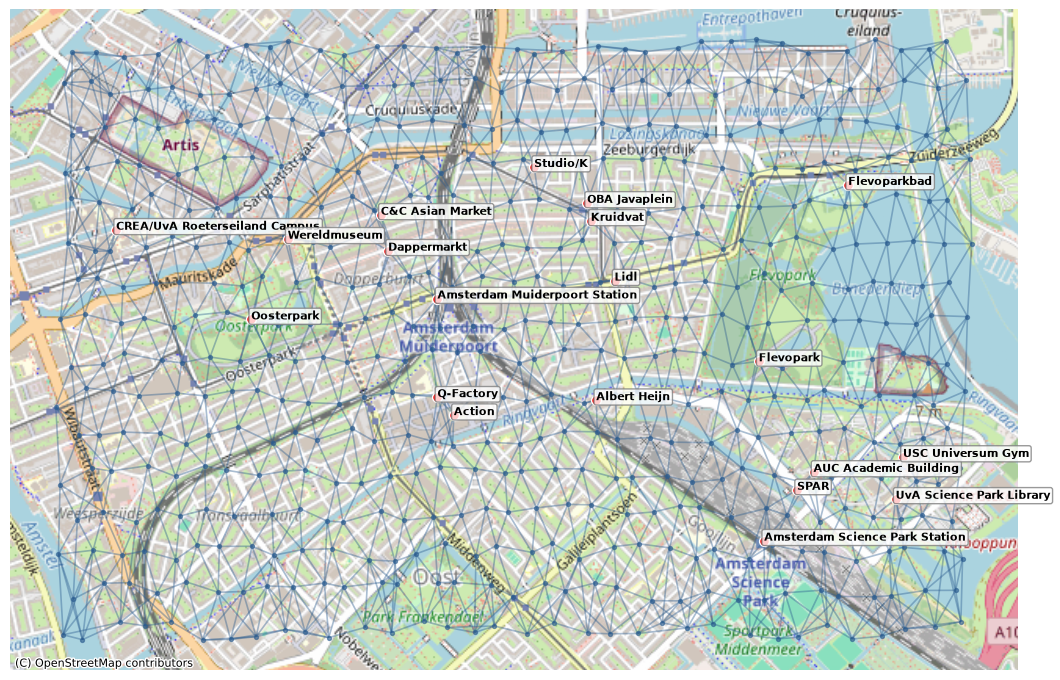

In [1]:
import numpy as np

from science_park_map import location_names, location_coords, bounds, gdf
from make_mesh import jittered_hex_grid_points, edges_from_knn
from plot_mesh import plot_mesh

### make micro-links

junction_coords = jittered_hex_grid_points(
    bounds,
    spacing=0.0015,
    jitter=0.25,
    seed=0
)

flipped_location_coords = [(lon, lat) for lat, lon in location_coords]
flipped_coords = np.vstack([flipped_location_coords, junction_coords])

micro_links = edges_from_knn(flipped_coords, k=6)

print("Location Coords sample:", flipped_coords[0])
print("Junction Coords sample:", junction_coords[0] if len(junction_coords) > 0 else "EMPTY GRID")
print("Total Bounds of your map:", bounds)

### plot

plot_mesh(flipped_coords, micro_links)

Now that we have our initial tubing, we will adapt it to connect our student destinations. This is how the adaptation cycle works:
  1. Choose source node i and sink node j randomly from the list of locations
  2. Given I0 amount of fluid injected into source node i and drained through sink node j, calculate the amount of flux. The flux is given by the equation Q = D*(p(j) - p(i)) / L, where Q is the flux in the tube going from node i to node j, D is the conductivity of the tube, p(j) is the pressure at node j, p(i) is the pressure at node i, and L is the length of the tube.
  3. Update the conductivity D of each tube based on its flux, using parameter gamma.

Essentially, the "tubes" (links representing possible Sciencemobile routes) that are used to convey "fluid" (representing students) more often are strengthened, while those that are used less often are weakened.

Note that we are using two important parameters: I0 and gamma. I0 is the amount of fluid injected into the source node and drained by the sink node. Gamma determines the relationship between the flux through a link at a given timestep and the amount by which we alter its conductivity. For now, we will set I0=1 and gamma=1. This means that a moderate amount of fluid is introduced at each time step, and there is a simple proportional relationship between the change in conductivity and the flux through a given link.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from shapely.geometry import LineString, Point

from adapt_network import (solve_pressures,
                           compute_flux,
                           update_conductivity,
                           conductivity_to_linewidths,
                           get_bounds_from_segments_and_points,
                           plot_conductivity_snapshots)

coords = flipped_coords

def run_simulation(coords,
                   micro_links,
                   n_steps=1000,
                   seed=0,
                   t_btwn_snapshots=100,
                   I0=1.0,
                   gamma=1.0):
    
    rng = np.random.default_rng(seed)

    num_links = len(micro_links)
    num_nodes = len(coords)

    link_is = [micro_links[i]["node_i"].to_numpy(dtype=int) for i in range(num_links)]
    link_js = [micro_links[i]["node_j"].to_numpy(dtype=int) for i in range(num_links)]
    lengths = [micro_links[i]["length_m"].to_numpy(dtype=float) for i in range(num_links)]

    # make array for keeping track of conductivities
    D = np.ones(num_links)

    snapshots = [{"step": 0,
                "conductivity": D.copy(),
                }]
    
    node_indices = range(len(coords))
    
    for t in range(n_steps):
        # choose source and sink node indices randomly
        source_node, sink_node = rng.choice(
            node_indices,
            size=2,
            replace=False,
        )

        # create array of pressures corresponding to ...
        pressures = solve_pressures(
            num_nodes=num_nodes,
            link_is=link_is,
            link_js=link_js,
            lengths=lengths,
            D=D,
            source_node=source_node,
            sink_node=sink_node,
            I0=I0,
        )

        Q = compute_flux(
            link_is=link_is,
            link_js=link_js,
            lengths=lengths,
            D=D,
            pressures=pressures,
        )

        D = update_conductivity(
            D=D,
            Q=Q,
            dt=0.1,
            gamma=gamma,
            D_min=1e-4,
        )

        if t % t_btwn_snapshots == 0:
            print(
                "step",
                t,
                "source",
                source_node,
                "sink",
                sink_node,
                "D min/max",
                D.min(),
                D.max(),
            )

        snapshots.append({
                "step": t,
                "conductivity": D.copy(),
            })
        
    edge_segments = make_edge_segments_from_nodes(
    node_coords=node_coords,
    edge_i=link_is,
    edge_j=link_js,
    )

    plot_conductivity_snapshots(
    edge_segments=edge_segments,
    food_coords=coords,
    snapshots=snapshots,
    )
    
    return

run_simulation(coords=coords,
                micro_links=micro_links,
                n_steps=10000,
                seed=0,
                t_btwn_snapshots=2000,
                I0=1.0,
                gamma=1.0)

ImportError: cannot import name 'Linestring' from 'shapely.geometry' (/Users/komarinschool/slime-mold-notebook/.venv/lib/python3.13/site-packages/shapely/geometry/__init__.py)

Repeat the simulation, this time setting I0 to 1.15 and gamma to [value]. [expected result] (''') Once you have found a combination of parameters that leads to a network that looks like it would be useful among AUC students, run it with n_steps=30000 to see what exact network the slime mold finally settles on.